# 06 — End-to-end streaming run, three-strategy Home Battery comparison

The digital twin streams a synthetic DE-style price curve and a manually-listed
appliance-onset stream, ticking **three independent strategies** in parallel so
their costs accrue against the same realized prices.

**Strategies:**
- `baseline` — naive ASAP household policy: no price awareness, no battery.
- `optimizer_nobatt` — MPC + LangGraph optimizer: shifts loads to cheap slots, no battery.
- `optimizer_batt` — MPC optimizer + Home Battery (13.5 kWh / 5 kW).

**Battery plots added:**
- State-of-charge trajectory vs realized price (battery fills troughs, empties at peaks).
- Charge/discharge power vs price (buy-low / spend-high).
- Three-strategy cumulative-cost comparison — quantifying the battery savings.
- Representative-day dispatch showing the battery covering the evening peak.

> **Run vs. reuse.** Every plot cell below reads only the parquet logs in
> `data/cache`, so a previous run is enough to render the whole notebook. The
> first code cell exposes a `RUN_SIM` flag: it defaults to reusing those cached
> logs (instant) and only runs the slow 1 Hz simulation when they are missing.
> Set `RUN_SIM = True` to force a fresh run after changing `SIM_HOURS` (default
> 48 — a full showcase, ~30 min at 1 Hz; drop to 1 for a ~120 s CI-safe smoke
> run), a strategy, or the price feed. With real SMARD prices
> (`scripts/fetch_smard_prices.py` + `digital_twin.main()`), a cached price file
> makes start-up instant.

In [1]:
import sys, re
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # render figures in Jupyter
except NameError:
    matplotlib.use("Agg")  # headless fallback (plain `python`, no IPython)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
try:
    from IPython.display import display
except ImportError:
    display = print

sys.path.insert(0, str(Path.cwd().parent))

from aerogrid.config import (
    BatterySpec, SLOT_LOG_PATH, EVENT_LOG_PATH,
    EV_DEADLINE_HOUR, HEATER_DEADLINES,
    HOME_BATTERY_CAPACITY_KWH, HOUSE_POWER_CAP_KW,
    HITL_AUTO_RESPONSES, SHORT_HORIZON_SLOTS,
)
from aerogrid.sim.digital_twin import run
from aerogrid.sim.streamer import Streamer
from aerogrid.sim.strategies import BaselineStrategy, OptimizerStrategy, Strategy


class _SyntheticFeed:
    """Cheap-night / expensive-day price curve (no network required).

    Tier 1 (cheap): 15 EUR/MWh during 22:00-06:00 UTC.
    Tier 2 (expensive): 85 EUR/MWh during 06:00-22:00 UTC.
    """

    def __init__(self, start, end):
        idx = pd.date_range(
            start - timedelta(days=7), end + timedelta(days=1),
            freq="15min", tz="UTC",
        )
        hod = idx.hour
        lbmp = np.where((hod >= 22) | (hod < 6), 15.0, 85.0).astype(np.float32)
        self.df = pd.DataFrame({"timestamp": idx, "lbmp": lbmp})

    def history(self, now):
        return self.df[self.df['timestamp'] < now]

    def realized(self, now):
        slot_min = (now.minute // 15) * 15
        slot = now.replace(minute=slot_min, second=0, microsecond=0)
        row = self.df[self.df['timestamp'] == slot]
        return float(row['lbmp'].iloc[0]) if not row.empty else None


# ── Run a fresh simulation, or reuse a previous one? ────────────────────
# Every plot cell below reads ONLY the parquet logs in data/cache, so a prior
# run is enough to render the whole notebook. The 1 Hz streamer is slow
# (SIM_HOURS=48 takes ~30 min), so by default we SKIP the simulation whenever
# those logs already exist and just load them. Flip RUN_SIM to force a choice:
#   RUN_SIM = True  -> always re-simulate (do this after changing SIM_HOURS,
#                      a strategy, or the price feed)
#   RUN_SIM = False -> always reuse the cached logs (fast; the default once a
#                      run exists)
SIM_HOURS = 48
have_logs = SLOT_LOG_PATH.exists() and EVENT_LOG_PATH.exists()
RUN_SIM = not have_logs

if not RUN_SIM:
    mtime = datetime.fromtimestamp(SLOT_LOG_PATH.stat().st_mtime, tz=timezone.utc)
    print("Reusing cached logs from a previous run "
          "(set RUN_SIM=True above to re-simulate):")
    print(f"  {SLOT_LOG_PATH}")
    print(f"  last written: {mtime:%Y-%m-%d %H:%M UTC}")
else:
    # Adjust SIM_HOURS above to trade off detail vs runtime.
    # SIM_HOURS = 1  runs in ~120 s (CI-safe).
    # SIM_HOURS = 48 gives a full showcase but takes ~30 minutes at 1 Hz.

    # Start at 21:00 UTC so the cheap overnight window (22:00) arrives within the run.
    start = datetime(2026, 4, 3, 21, 0, tzinfo=timezone.utc)
    end   = start + timedelta(hours=SIM_HOURS)
    feed  = _SyntheticFeed(start, end)

    streamer = Streamer(realized_price_provider=feed.realized)
    # Onsets within the first hour: dishwasher at +15 min, washing machine at +30 min.
    streamer.add_onset('dishwasher',      start + timedelta(minutes=15))
    streamer.add_onset('washing_machine', start + timedelta(minutes=30))

    baseline = BaselineStrategy(name='baseline')
    optimizer_nobatt = OptimizerStrategy(
        name='optimizer_nobatt',
        price_history_provider=feed.history,
        price_oracle_impl='naive',
        horizon_slots=SHORT_HORIZON_SLOTS,
        auto_confirm=True,
        auto_responses=HITL_AUTO_RESPONSES,
        battery_enabled=False,
    )
    optimizer_batt = OptimizerStrategy(
        name='optimizer_batt',
        price_history_provider=feed.history,
        price_oracle_impl='naive',
        horizon_slots=SHORT_HORIZON_SLOTS,
        auto_confirm=True,
        auto_responses=HITL_AUTO_RESPONSES,
        battery_enabled=True,
    )
    strategies = [baseline, optimizer_nobatt, optimizer_batt]

    SLOT_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
    summary = run(
        strategies=strategies,
        streamer=streamer,
        start=start,
        end=end,
        slot_log_path=SLOT_LOG_PATH,
        event_log_path=EVENT_LOG_PATH,
    )

    print("\n=== simulation summary ===")
    print(f"samples:           {summary['n_samples']:,}")
    print(f"onsets suppressed: {summary['n_suppressed_total']}")
    print(f"slot log:          {summary['slot_log_path']}")
    print()
    print(f"{'strategy':<20} {'cost (EUR)':>12}")
    for s in summary['strategies']:
        print(f"  {s['name']:<18} {s['cumulative_cost_eur']:>12.3f}")
    base_c = next((s['cumulative_cost_eur'] for s in summary['strategies'] if s['name']=='baseline'), None)
    if base_c and abs(base_c) > 1e-9:
        print()
        for s in summary['strategies']:
            if s['name'] == 'baseline':
                continue
            saved = (1.0 - s['cumulative_cost_eur'] / base_c) * 100
            print(f"  {s['name']} vs baseline: {saved:+.1f}% savings")

Reusing cached logs from a previous run (set RUN_SIM=True above to re-simulate):
  /Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/data/cache/slot_log.parquet
  last written: 2026-06-02 16:05 UTC


strategies: ['baseline', 'optimizer_nobatt', 'optimizer_batt']
slot log: 192 rows x 51 cols


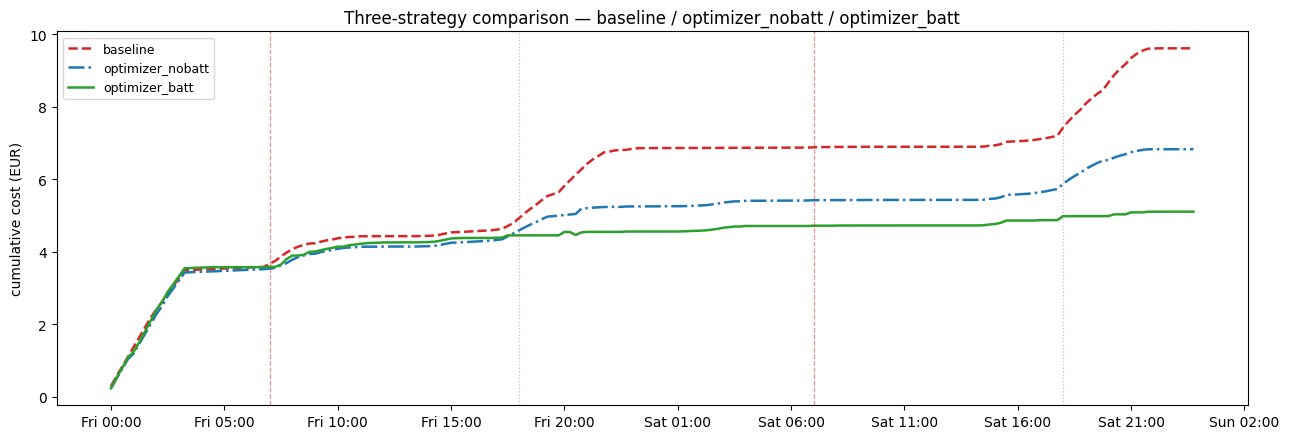

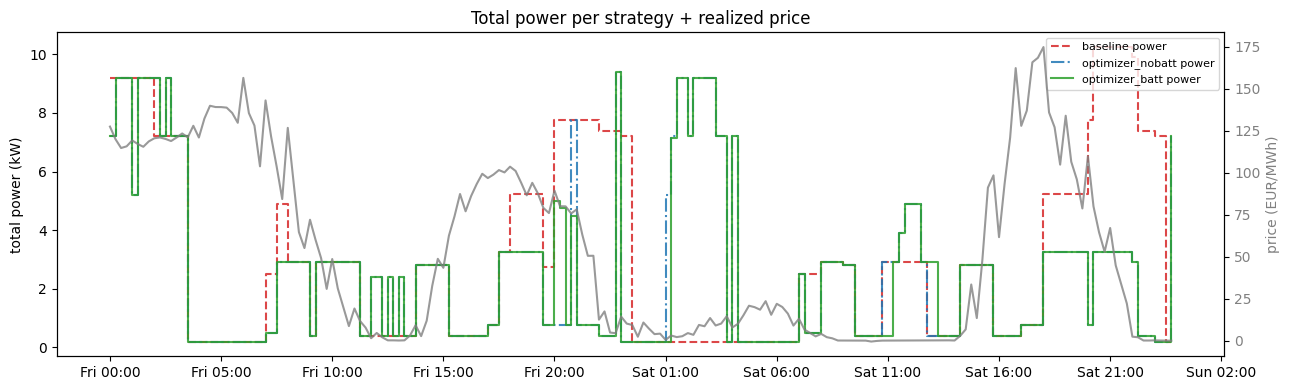

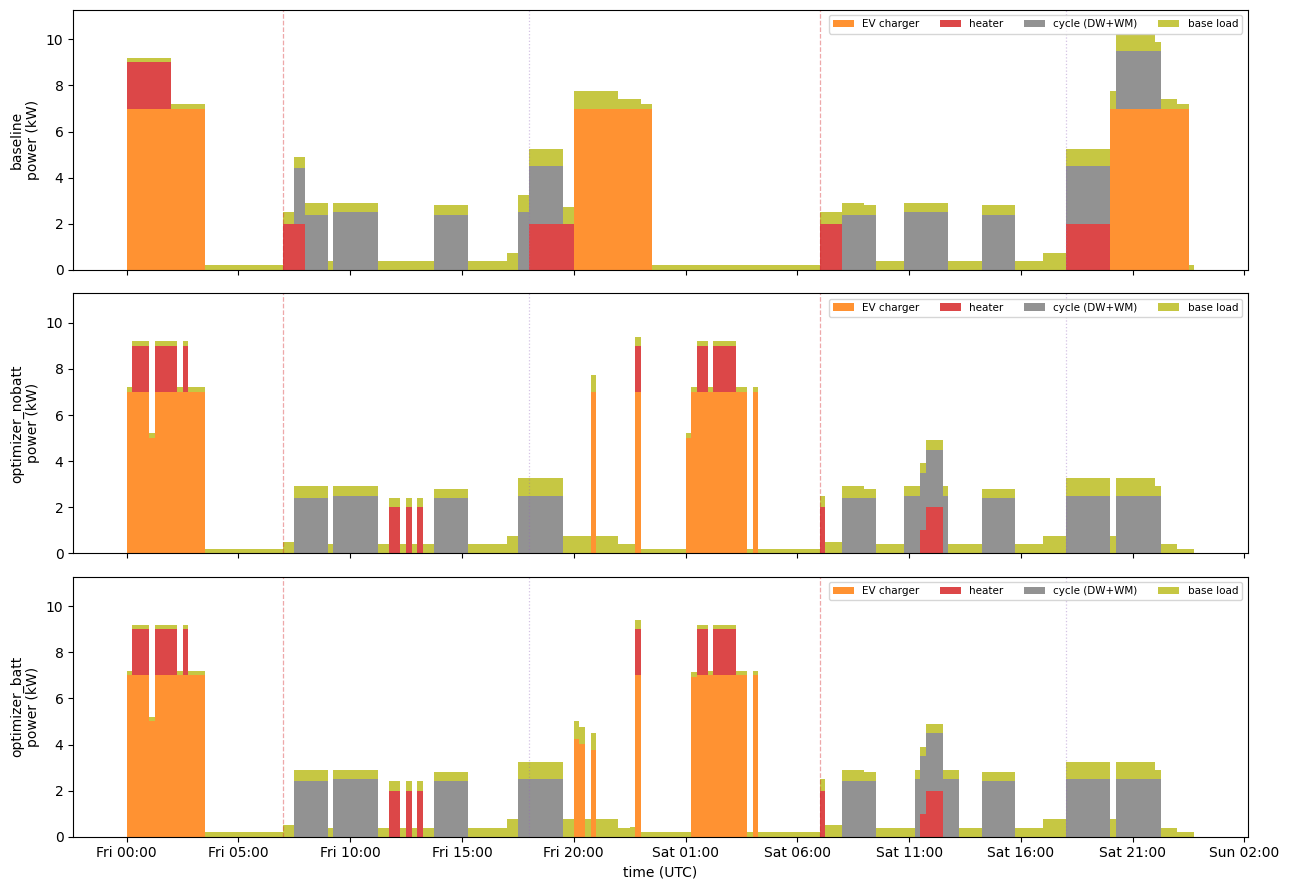

In [2]:
# Load outputs and set up shared plot helpers.
slot_df  = pd.read_parquet(SLOT_LOG_PATH)
event_df = pd.read_parquet(EVENT_LOG_PATH)
slot_df["timestamp"]  = pd.to_datetime(slot_df["timestamp"], utc=True)
event_df["timestamp"] = pd.to_datetime(event_df["timestamp"], utc=True)
slot_df  = slot_df.sort_values("timestamp").reset_index(drop=True)
event_df = event_df.sort_values("timestamp").reset_index(drop=True)

strategy_names = [
    m.group(1)
    for m in (re.match(r'(.+)_cum_cost_eur$', c) for c in slot_df.columns)
    if m is not None
]
print(f"strategies: {strategy_names}")
print(f"slot log: {len(slot_df)} rows x {len(slot_df.columns)} cols")

t_min, t_max = slot_df['timestamp'].min(), slot_df['timestamp'].max()
duration_h   = (t_max - t_min).total_seconds() / 3600.0
locator   = mdates.HourLocator(interval=max(1, int(duration_h // 8) or 1))
formatter = mdates.DateFormatter("%a %H:%M")

def deadline_kind(hour):
    is_ev     = hour == EV_DEADLINE_HOUR
    is_heater = any(d.hour == hour for d in HEATER_DEADLINES)
    if is_ev and is_heater:
        return "EV & heater deadline", "#d62728", "--"
    if is_ev:
        return "EV deadline", "#d62728", "--"
    return "heater deadline", "#9467bd", ":"

deadline_hours = sorted({EV_DEADLINE_HOUR} | {d.hour for d in HEATER_DEADLINES})
deadlines = []
for day in pd.date_range(t_min.floor("D"), t_max.ceil("D"), freq="D", tz="UTC"):
    for hour in deadline_hours:
        t = day.replace(hour=hour, minute=0, second=0, microsecond=0)
        if t_min <= t <= t_max:
            label, color, ls = deadline_kind(hour)
            deadlines.append((t, label, color, ls))

_CURVE_COLOR = {
    "baseline":         "#d62728",
    "optimizer_nobatt": "#1f77b4",
    "optimizer_batt":   "#2ca02c",
}
_CURVE_LS = {
    "baseline":         "--",
    "optimizer_nobatt": "-.",
    "optimizer_batt":   "-",
}

# ── Cumulative cost ─────────────────────────────────────────────────────
fig1, ax_cost = plt.subplots(figsize=(13, 4.5))
for name in strategy_names:
    ax_cost.plot(slot_df['timestamp'], slot_df[f'{name}_cum_cost_eur'],
                 lw=1.8, ls=_CURVE_LS.get(name, '-'),
                 color=_CURVE_COLOR.get(name, 'grey'), label=name)
supp_ev = event_df[event_df['event_type'] == 'onset_suppressed']
for _, row in supp_ev.iterrows():
    ax_cost.axvline(row['timestamp'], color='black', alpha=0.5, lw=0.8)
for t, label, color, ls in deadlines:
    ax_cost.axvline(t, color=color, ls=ls, lw=0.9, alpha=0.5)
ax_cost.set_ylabel("cumulative cost (EUR)")
ax_cost.set_title("Three-strategy comparison — baseline / optimizer_nobatt / optimizer_batt")
ax_cost.legend(fontsize=9)
ax_cost.xaxis.set_major_locator(locator)
ax_cost.xaxis.set_major_formatter(formatter)
fig1.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout(); plt.show()

# ── Total power + price ─────────────────────────────────────────────────
fig2, ax_pp = plt.subplots(figsize=(13, 4.0))
ax_price2 = ax_pp.twinx()
for name in strategy_names:
    ax_pp.step(slot_df['timestamp'], slot_df[f'{name}_total_kw'],
               where='post', lw=1.5, ls=_CURVE_LS.get(name, '-'),
               color=_CURVE_COLOR.get(name, 'grey'), alpha=0.85, label=f'{name} power')
ax_price2.plot(slot_df['timestamp'], slot_df['price_eur_mwh'], color='grey', lw=1.5, alpha=0.8)
ax_price2.set_ylabel("price (EUR/MWh)", color="grey")
ax_price2.tick_params(axis='y', labelcolor='grey')
ax_pp.set_ylabel("total power (kW)")
ax_pp.set_title("Total power per strategy + realized price")
ax_pp.legend(fontsize=8, loc='upper right')
ax_pp.xaxis.set_major_locator(locator); ax_pp.xaxis.set_major_formatter(formatter)
fig2.autofmt_xdate(rotation=0, ha='center'); plt.tight_layout(); plt.show()

# ── Per-strategy stacked breakdown ──────────────────────────────────────
n_strats = len(strategy_names)
breakdown_layers = [
    ('ev_kw',        'EV charger',    '#ff7f0e'),
    ('heater_kw',    'heater',        '#d62728'),
    ('cycle_kw',     'cycle (DW+WM)', '#7f7f7f'),
    ('base_load_kw', 'base load',     '#bcbd22'),
]
shared_y_max = max(slot_df[f'{name}_total_kw'].max() for name in strategy_names) * 1.1
fig3, axes3 = plt.subplots(n_strats, 1, figsize=(13, 3.0 * n_strats), sharex=True)
if n_strats == 1: axes3 = [axes3]
for ax, name in zip(axes3, strategy_names):
    series = [
        (slot_df[f'{name}_{col}'].values if f'{name}_{col}' in slot_df.columns else np.zeros(len(slot_df)))
        for col, _, _ in breakdown_layers
    ]
    ax.stackplot(slot_df['timestamp'], *series,
                 labels=[lbl for _,lbl,_ in breakdown_layers],
                 colors=[c for _,_,c in breakdown_layers],
                 alpha=0.85, step='post')
    ax.set_ylabel(f'{name}\npower (kW)')
    ax.set_ylim(0, shared_y_max)
    ax.legend(handles=[Patch(facecolor=c, label=lbl, alpha=0.85) for _,lbl,c in breakdown_layers],
              loc='upper right', fontsize=7.5, ncol=len(breakdown_layers))
    for t, label, color, ls in deadlines:
        ax.axvline(t, color=color, ls=ls, lw=0.9, alpha=0.4)
axes3[-1].xaxis.set_major_locator(locator); axes3[-1].xaxis.set_major_formatter(formatter)
axes3[-1].set_xlabel('time (UTC)')
fig3.autofmt_xdate(rotation=0, ha='center'); plt.tight_layout(); plt.show()

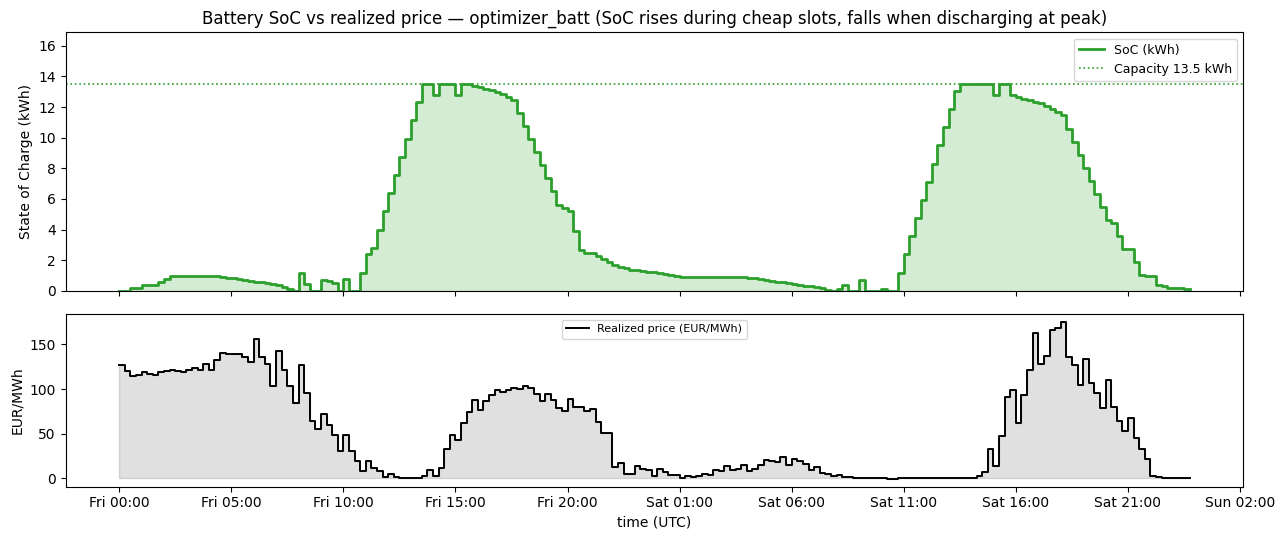

Battery peak SoC: 13.50 kWh  (capacity 13.5 kWh)
SoC ever negative: False


In [3]:
# Battery plot 1: SoC trajectory vs realized price.
batt_name  = 'optimizer_batt'
soc_col_nm = f'{batt_name}_soc_kwh'
assert soc_col_nm in slot_df.columns, f'Missing column {soc_col_nm}'

fig4, (ax41, ax42) = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 2]})
soc_series = slot_df[soc_col_nm]
ax41.step(slot_df['timestamp'], soc_series, where='post', color='#2ca02c', lw=2.0, label='SoC (kWh)')
ax41.fill_between(slot_df['timestamp'], soc_series, step='post', alpha=0.2, color='#2ca02c')
ax41.axhline(HOME_BATTERY_CAPACITY_KWH, color='#2ca02c', ls=':', lw=1.2,
             label=f'Capacity {HOME_BATTERY_CAPACITY_KWH} kWh')
ax41.set_ylabel("State of Charge (kWh)")
ax41.set_title(
    "Battery SoC vs realized price — optimizer_batt"
    " (SoC rises during cheap slots, falls when discharging at peak)"
)
ax41.set_ylim(0, HOME_BATTERY_CAPACITY_KWH * 1.25)
ax41.legend(fontsize=9)
ax42.step(slot_df['timestamp'], slot_df['price_eur_mwh'], where='post', color='k', lw=1.4,
          label='Realized price (EUR/MWh)')
ax42.fill_between(slot_df['timestamp'], slot_df['price_eur_mwh'], step='post', alpha=0.12, color='k')
ax42.set_ylabel("EUR/MWh")
ax42.set_xlabel("time (UTC)")
ax42.legend(fontsize=8)
ax42.xaxis.set_major_locator(locator); ax42.xaxis.set_major_formatter(formatter)
fig4.autofmt_xdate(rotation=0, ha='center'); plt.tight_layout(); plt.show()

print(f'Battery peak SoC: {soc_series.max():.2f} kWh  (capacity {HOME_BATTERY_CAPACITY_KWH} kWh)')
print(f'SoC ever negative: {(soc_series < -1e-6).any()}')
assert (soc_series >= -1e-6).all(), 'SoC went negative'

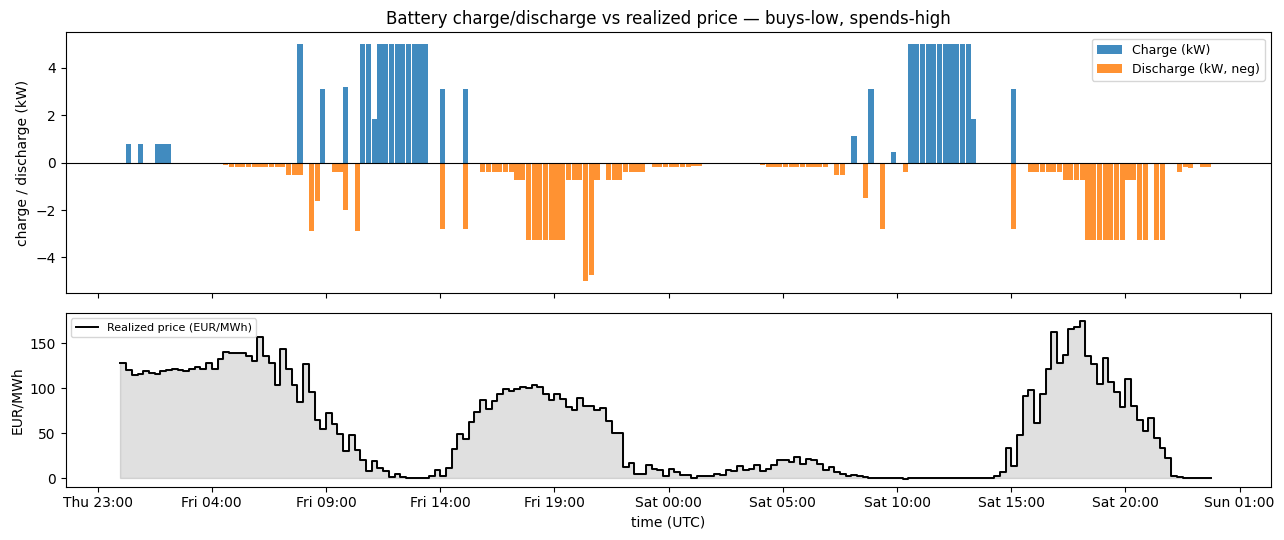

Charging slots: 38,  discharging slots: 106


In [4]:
# Battery plot 2: charge/discharge vs price — buy-low / spend-high.
chg_col = f'{batt_name}_battery_charge_kw'
dis_col = f'{batt_name}_battery_discharge_kw'
assert chg_col in slot_df.columns
assert dis_col in slot_df.columns

fig5, (ax51, ax52) = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 2]})
chg_s = slot_df[chg_col]; dis_s = slot_df[dis_col]
width_days = 15 * 0.9 / (60 * 24)
ax51.bar(slot_df['timestamp'], chg_s, width=width_days, color='#1f77b4',
         alpha=0.85, align='edge', label='Charge (kW)')
ax51.bar(slot_df['timestamp'], -dis_s, width=width_days, color='#ff7f0e',
         alpha=0.85, align='edge', label='Discharge (kW, neg)')
ax51.axhline(0, color='black', lw=0.8)
ax51.set_ylabel("charge / discharge (kW)")
ax51.set_title("Battery charge/discharge vs realized price — buys-low, spends-high")
ax51.legend(fontsize=9)
ax52.step(slot_df['timestamp'], slot_df['price_eur_mwh'], where='post', color='k', lw=1.4,
          label='Realized price (EUR/MWh)')
ax52.fill_between(slot_df['timestamp'], slot_df['price_eur_mwh'], step='post', alpha=0.12, color='k')
ax52.set_ylabel("EUR/MWh")
ax52.set_xlabel("time (UTC)")
ax52.legend(fontsize=8)
ax52.xaxis.set_major_locator(locator); ax52.xaxis.set_major_formatter(formatter)
fig5.autofmt_xdate(rotation=0, ha='center'); plt.tight_layout(); plt.show()

print(f'Charging slots: {(chg_s > 0.01).sum()},  discharging slots: {(dis_s > 0.01).sum()}')

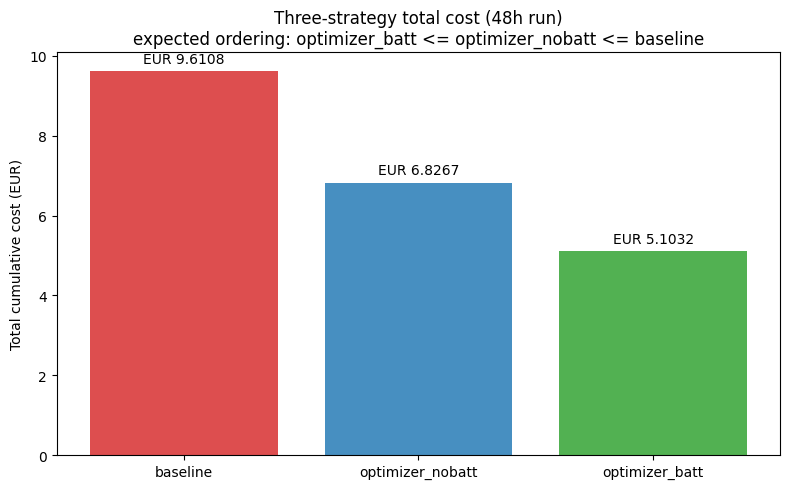


Final costs:
  baseline               EUR 9.6108
  optimizer_nobatt       EUR 6.8267
  optimizer_batt         EUR 5.1032

  optimizer_nobatt vs baseline: +29.0% savings
  optimizer_batt vs baseline: +46.9% savings

Cost ordering verified: batt <= nobatt <= baseline


In [5]:
# Battery plot 3: three-strategy cumulative-cost comparison.
final_costs = {name: slot_df[f'{name}_cum_cost_eur'].iloc[-1] for name in strategy_names}
colors6 = [_CURVE_COLOR.get(n, 'grey') for n in strategy_names]
fig6, ax6 = plt.subplots(figsize=(8, 5))
bars6 = ax6.bar(list(final_costs.keys()), list(final_costs.values()), color=colors6, alpha=0.82)
ax6.bar_label(bars6, fmt='EUR %.4f', padding=4, fontsize=10)
ax6.set_ylabel("Total cumulative cost (EUR)")
ax6.set_title(
    f'Three-strategy total cost ({duration_h:.0f}h run)\n'
    'expected ordering: optimizer_batt <= optimizer_nobatt <= baseline'
)
ax6.axhline(0, color='black', lw=0.7)
plt.tight_layout(); plt.show()
print('\nFinal costs:')
for name, cost in final_costs.items():
    print(f'  {name:<22} EUR {cost:.4f}')
base_v = final_costs.get('baseline')
if base_v and abs(base_v) > 1e-9:
    print()
    for name in strategy_names:
        if name == 'baseline': continue
        saved = (1.0 - final_costs[name] / base_v) * 100
        print(f'  {name} vs baseline: {saved:+.1f}% savings')
if all(n in final_costs for n in ('optimizer_batt', 'optimizer_nobatt', 'baseline')):
    assert final_costs['optimizer_batt'] <= final_costs['optimizer_nobatt'] + 0.01
    assert final_costs['optimizer_nobatt'] <= final_costs['baseline'] + 0.01
    print('\nCost ordering verified: batt <= nobatt <= baseline')

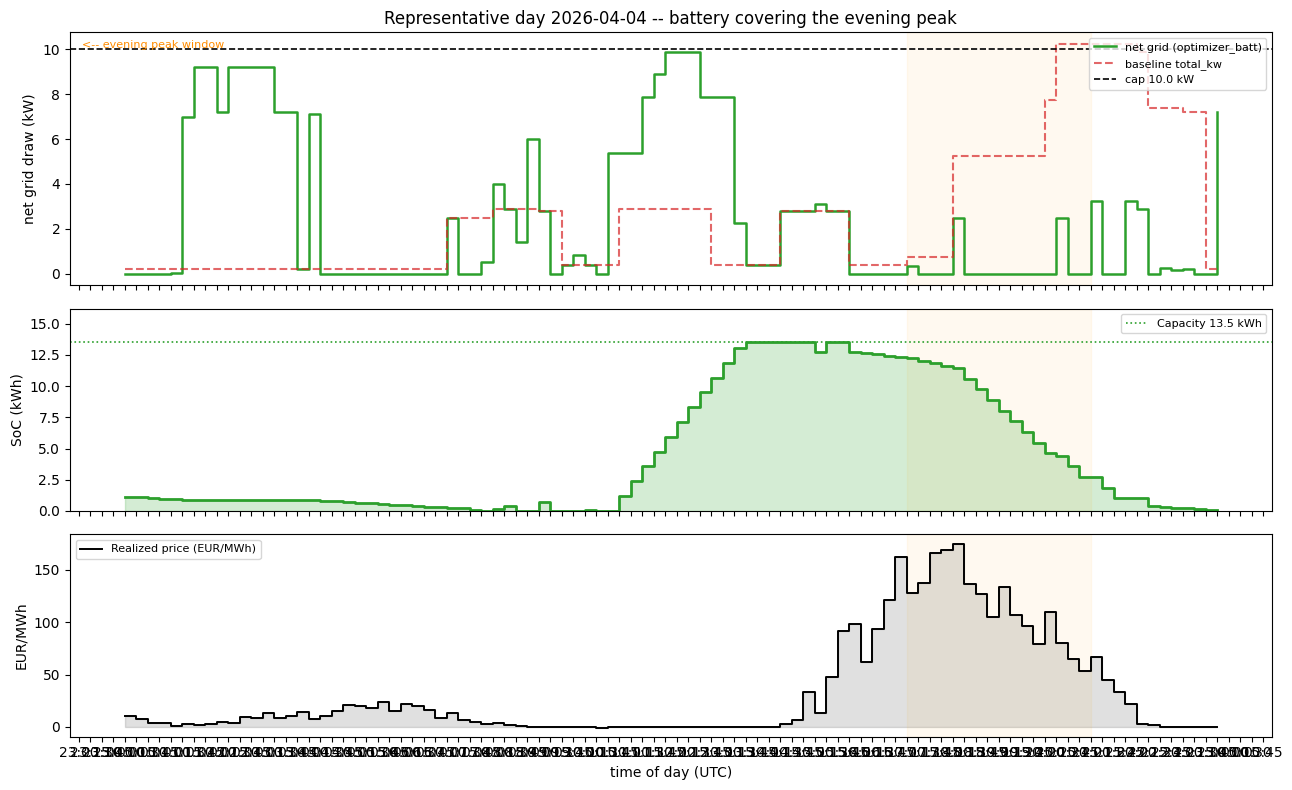

Showing: 2026-04-04


In [6]:
# Battery plot 4: representative-day dispatch.
# With SIM_HOURS = 1 there is only 1 slot, so we show that one slot's data.
# With SIM_HOURS >= 24 the plot shows the day with the highest evening peak.
slot_df['_hour'] = slot_df['timestamp'].dt.hour
slot_df['_date'] = slot_df['timestamp'].dt.date

if len(slot_df['_date'].unique()) >= 2:
    evening_mask = slot_df['_hour'].between(17, 21)
    evening_avg  = slot_df[evening_mask].groupby('_date')['price_eur_mwh'].mean()
    rep_date = evening_avg.idxmax()
    day_df   = slot_df[slot_df['_date'] == rep_date].copy()
else:
    # Short run: use all available slots.
    rep_date = slot_df['_date'].iloc[0]
    day_df   = slot_df.copy()

fig7, axes7 = plt.subplots(3, 1, figsize=(13, 8), sharex=True,
                            gridspec_kw={'height_ratios': [2.5, 2, 2]})
ax71, ax72, ax73 = axes7

net_col_d = f'{batt_name}_net_grid_kw'
if net_col_d in day_df.columns:
    ax71.step(day_df['timestamp'], day_df[net_col_d],
              where='post', color='#2ca02c', lw=1.8, label=f'net grid ({batt_name})')
ax71.step(day_df['timestamp'], day_df['baseline_total_kw'],
          where='post', color='#d62728', lw=1.5, ls='--', alpha=0.7, label='baseline total_kw')
ax71.axhline(HOUSE_POWER_CAP_KW, color='black', ls='--', lw=1.2,
             label=f'cap {HOUSE_POWER_CAP_KW} kW')
ax71.set_ylabel("net grid draw (kW)")
ax71.set_title(f'Representative day {rep_date} -- battery covering the evening peak')
ax71.legend(fontsize=8, loc='upper right')

soc_col_d = f'{batt_name}_soc_kwh'
if soc_col_d in day_df.columns:
    ax72.step(day_df['timestamp'], day_df[soc_col_d], where='post', color='#2ca02c', lw=2.0)
    ax72.fill_between(day_df['timestamp'], day_df[soc_col_d], step='post', alpha=0.2, color='#2ca02c')
    ax72.axhline(HOME_BATTERY_CAPACITY_KWH, color='#2ca02c', ls=':', lw=1.2,
                 label=f'Capacity {HOME_BATTERY_CAPACITY_KWH} kWh')
    ax72.set_ylabel("SoC (kWh)")
    ax72.set_ylim(0, HOME_BATTERY_CAPACITY_KWH * 1.2)
    ax72.legend(fontsize=8)

ax73.step(day_df['timestamp'], day_df['price_eur_mwh'], where='post', color='k', lw=1.4,
          label='Realized price (EUR/MWh)')
ax73.fill_between(day_df['timestamp'], day_df['price_eur_mwh'], step='post', alpha=0.12, color='k')
ax73.set_ylabel("EUR/MWh")
ax73.set_xlabel("time of day (UTC)")
ax73.legend(fontsize=8)

# Shade evening peak window if it falls in the visible range.
t0_eve = pd.Timestamp(rep_date, tz='UTC').replace(hour=17)
t1_eve = pd.Timestamp(rep_date, tz='UTC').replace(hour=21)
for ax in axes7:
    ax.axvspan(t0_eve, t1_eve, alpha=0.06, color='orange')
ax71.text(0.01, 0.97, '<-- evening peak window', transform=ax71.transAxes,
          va='top', fontsize=8, color='darkorange')

ax73.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 15, 30, 45]))
ax73.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
fig7.autofmt_xdate(rotation=0, ha='center'); plt.tight_layout(); plt.show()
print(f'Showing: {rep_date}')
slot_df.drop(columns=['_hour', '_date'], inplace=True, errors='ignore')

In [7]:
# Raw data tables.
core_cols = ['timestamp', 'price_eur_mwh', 'onsets', 'suppressed_onsets']
sample_cols = core_cols.copy()
for name in strategy_names:
    sample_cols += [f'{name}_ev_kw', f'{name}_base_load_kw', f'{name}_cum_cost_eur']
    for bc in (f'{name}_battery_charge_kw', f'{name}_soc_kwh', f'{name}_net_grid_kw'):
        if bc in slot_df.columns:
            sample_cols.append(bc)
print('=== slot_log (first 12 rows, sample columns) ===')
display(slot_df[[c for c in sample_cols if c in slot_df.columns]].head(12))
print('\n=== event_log (first 15 rows) ===')
display(event_df[['timestamp','strategy','event_type','appliance',
                   'power_kw','cum_cost_eur','price_eur_mwh','detail']].head(15))
supp_disp = event_df[event_df['event_type'] == 'onset_suppressed']
if not supp_disp.empty:
    print(f'\n=== suppressed onsets ({len(supp_disp)}) ===')
    display(supp_disp[['timestamp', 'appliance', 'detail']])
else:
    print('\nNo onsets were suppressed.')

=== slot_log (first 12 rows, sample columns) ===


,timestamp,price_eur_mwh,onsets,suppressed_onsets,baseline_ev_kw,baseline_base_load_kw,baseline_cum_cost_eur,baseline_battery_charge_kw,baseline_soc_kwh,baseline_net_grid_kw,...,optimizer_nobatt_cum_cost_eur,optimizer_nobatt_battery_charge_kw,optimizer_nobatt_soc_kwh,optimizer_nobatt_net_grid_kw,optimizer_batt_ev_kw,optimizer_batt_base_load_kw,optimizer_batt_cum_cost_eur,optimizer_batt_battery_charge_kw,optimizer_batt_soc_kwh,optimizer_batt_net_grid_kw
0,2026-04-03 00:00:00+00:00,127.53,,,7.0,0.2,0.293319,0.0,0.0,9.2,...,0.229554,0.0,0.0,7.2,7.0,0.2,0.229554,0.0,0.00,7.2
1,2026-04-03 00:15:00+00:00,120.00,,,7.0,0.2,0.569319,0.0,0.0,9.2,...,0.505554,0.0,0.0,9.2,7.0,0.2,0.529554,0.8,0.00,10.0
2,2026-04-03 00:30:00+00:00,114.76,,,7.0,0.2,0.833267,0.0,0.0,9.2,...,0.769502,0.0,0.0,9.2,7.0,0.2,0.793502,0.0,0.19,9.2
3,2026-04-03 00:45:00+00:00,115.77,,,7.0,0.2,1.099538,0.0,0.0,9.2,...,1.035773,0.0,0.0,9.2,7.0,0.2,1.082927,0.8,0.19,10.0
4,2026-04-03 01:00:00+00:00,119.28,,,7.0,0.2,1.373882,0.0,0.0,9.2,...,1.190837,0.0,0.0,5.2,5.0,0.2,1.237991,0.0,0.38,5.2
5,2026-04-03 01:15:00+00:00,117.16,,,7.0,0.2,1.643350,0.0,0.0,9.2,...,1.460305,0.0,0.0,9.2,7.0,0.2,1.507459,0.0,0.38,9.2
6,2026-04-03 01:30:00+00:00,115.50,,,7.0,0.2,1.909000,0.0,0.0,9.2,...,1.725955,0.0,0.0,9.2,7.0,0.2,1.796209,0.8,0.38,10.0
7,2026-04-03 01:45:00+00:00,118.73,,,7.0,0.2,2.182079,0.0,0.0,9.2,...,1.999034,0.0,0.0,9.2,7.0,0.2,2.093034,0.8,0.57,10.0
8,2026-04-03 02:00:00+00:00,120.59,,,7.0,0.2,2.399141,0.0,0.0,7.2,...,2.276391,0.0,0.0,9.2,7.0,0.2,2.394509,0.8,0.76,10.0
9,2026-04-03 02:15:00+00:00,121.05,,,7.0,0.2,2.617031,0.0,0.0,7.2,...,2.494281,0.0,0.0,7.2,7.0,0.2,2.612399,0.0,0.95,7.2



=== event_log (first 15 rows) ===


,timestamp,strategy,event_type,appliance,power_kw,cum_cost_eur,price_eur_mwh,detail
0,2026-04-03 00:00:00+00:00,baseline,ev_charging_start,ev_charger,7.0,0.000000,127.53,"charging at 7.00 kW, remaining 24.00 kWh"
1,2026-04-03 00:00:00+00:00,baseline,heater_on,heater,2.0,0.000000,127.53,"window 07:00, remaining 4.00 kWh"
2,2026-04-03 00:00:00+00:00,optimizer_nobatt,replan_triggered,NaN,NaN,0.000000,127.53,"kind=deadline_slip reason='need 3.4kW, current..."
3,2026-04-03 00:00:00+00:00,optimizer_nobatt,ev_setpoint_changed,ev_charger,7.0,0.000000,127.53,0.00 → 7.00 kW (solver=optimal)
4,2026-04-03 00:00:00+00:00,optimizer_batt,replan_triggered,NaN,NaN,0.000000,127.53,"kind=deadline_slip reason='need 3.4kW, current..."
5,2026-04-03 00:00:00+00:00,optimizer_batt,ev_setpoint_changed,ev_charger,7.0,0.000000,127.53,0.00 → 7.00 kW (solver=optimal)
6,2026-04-03 00:15:00+00:00,optimizer_nobatt,replan_triggered,NaN,NaN,0.229554,120.00,kind=periodic reason='15.0m since last'
7,2026-04-03 00:15:00+00:00,optimizer_nobatt,heater_setpoint_changed,heater,2.0,0.229554,120.00,0.00 → 2.00 kW
8,2026-04-03 00:15:00+00:00,optimizer_batt,replan_triggered,NaN,NaN,0.229554,120.00,kind=periodic reason='15.0m since last'
9,2026-04-03 00:15:00+00:00,optimizer_batt,heater_setpoint_changed,heater,2.0,0.229554,120.00,0.00 → 2.00 kW



No onsets were suppressed.


In [8]:
# Smoke checks.
assert not slot_df.empty, 'slot_log is empty'
assert not event_df.empty, 'event_log is empty'
assert strategy_names, 'no strategies discovered'
for name in strategy_names:
    required = {
        f'{name}_ev_kw', f'{name}_heater_kw', f'{name}_cycle_kw',
        f'{name}_total_kw', f'{name}_slot_cost_eur', f'{name}_cum_cost_eur',
        f'{name}_remaining_ev_kwh',
    }
    missing = required - set(slot_df.columns)
    assert not missing, f'strategy {name!r} missing columns: {missing}'
    assert slot_df[f'{name}_cum_cost_eur'].notna().all(), f'{name} cum_cost has NaNs'
if 'optimizer_batt' in strategy_names:
    batt_cols = {
        'optimizer_batt_battery_charge_kw', 'optimizer_batt_battery_discharge_kw',
        'optimizer_batt_soc_kwh', 'optimizer_batt_net_grid_kw',
    }
    assert batt_cols <= set(slot_df.columns), f'Missing: {batt_cols - set(slot_df.columns)}'
    soc_vals = slot_df['optimizer_batt_soc_kwh']
    assert (soc_vals >= -1e-6).all(), 'SoC went negative'
    print(f'  optimizer_batt peak SoC: {soc_vals.max():.2f} kWh')
if all(n in strategy_names for n in ('baseline', 'optimizer_nobatt', 'optimizer_batt')):
    fv = {n: slot_df[f'{n}_cum_cost_eur'].iloc[-1] for n in strategy_names}
    assert fv['optimizer_batt'] <= fv['optimizer_nobatt'] + 0.01, (
        f"Cost ordering: batt={fv['optimizer_batt']:.4f} > nobatt={fv['optimizer_nobatt']:.4f}"
    )
    assert fv['optimizer_nobatt'] <= fv['baseline'] + 0.01, (
        f"Cost ordering: nobatt={fv['optimizer_nobatt']:.4f} > baseline={fv['baseline']:.4f}"
    )
    print(f"  Cost ordering: batt={fv['optimizer_batt']:.4f} <= nobatt={fv['optimizer_nobatt']:.4f} <= baseline={fv['baseline']:.4f}")
for col in ('timestamp', 'price_eur_mwh', 'onsets', 'suppressed_onsets'):
    assert col in slot_df.columns, f'missing {col}'
for name in strategy_names:
    assert (event_df['strategy'] == name).any(), f'no events for strategy {name!r}'
assert (event_df['strategy'] == 'stream').any(), 'no stream-level events'
if 'baseline' in strategy_names:
    base_ev_types = set(event_df[event_df.strategy == 'baseline']['event_type'])
    assert 'ev_charging_start' in base_ev_types, 'expected ev_charging_start in baseline events'
    assert 'heater_on' in base_ev_types, 'expected heater_on in baseline events'
n_supp = (event_df['event_type'] == 'onset_suppressed').sum()
print(f'  suppressed onsets: {n_supp}')
print('All checks passed.')
print(f'  slot_log: {len(slot_df)} rows x {len(slot_df.columns)} cols')
print(f'  event_log: {len(event_df)} rows')
print(f'  strategies: {strategy_names}')

  optimizer_batt peak SoC: 13.50 kWh
  Cost ordering: batt=5.1032 <= nobatt=6.8267 <= baseline=9.6108
  suppressed onsets: 0
All checks passed.
  slot_log: 192 rows x 51 cols
  event_log: 2564 rows
  strategies: ['baseline', 'optimizer_nobatt', 'optimizer_batt']
